<a href="https://colab.research.google.com/github/Tansihq-jais/Encryptix/blob/main/Credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score

In [2]:
data_train=pd.read_csv("fraudTrain.csv")
data_test=pd.read_csv("fraudTest.csv")

In [3]:
full_data=pd.concat([data_train, data_test])

In [4]:
full_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [5]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155517 entries, 0 to 38895
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             155517 non-null  int64  
 1   trans_date_trans_time  155517 non-null  object 
 2   cc_num                 155517 non-null  int64  
 3   merchant               155517 non-null  object 
 4   category               155517 non-null  object 
 5   amt                    155517 non-null  float64
 6   first                  155517 non-null  object 
 7   last                   155517 non-null  object 
 8   gender                 155516 non-null  object 
 9   street                 155516 non-null  object 
 10  city                   155516 non-null  object 
 11  state                  155516 non-null  object 
 12  zip                    155516 non-null  float64
 13  lat                    155516 non-null  float64
 14  long                   155516 non-null  fl

In [6]:
full_data=full_data.dropna()

In [7]:
full_data.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


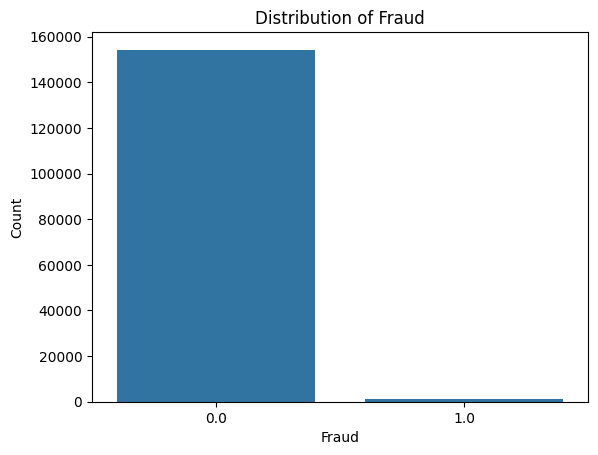

In [8]:
fraud_counts=full_data['is_fraud'].value_counts()
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title('Distribution of Fraud')
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.show()

In [9]:
full_data.duplicated().sum()

0

In [10]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155515 entries, 0 to 38894
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             155515 non-null  int64  
 1   trans_date_trans_time  155515 non-null  object 
 2   cc_num                 155515 non-null  int64  
 3   merchant               155515 non-null  object 
 4   category               155515 non-null  object 
 5   amt                    155515 non-null  float64
 6   first                  155515 non-null  object 
 7   last                   155515 non-null  object 
 8   gender                 155515 non-null  object 
 9   street                 155515 non-null  object 
 10  city                   155515 non-null  object 
 11  state                  155515 non-null  object 
 12  zip                    155515 non-null  float64
 13  lat                    155515 non-null  float64
 14  long                   155515 non-null  fl

In [11]:
fraud=full_data[full_data["is_fraud"]==1]
not_fraud=full_data[full_data["is_fraud"]==0]
print(fraud.shape[0])
print(not_fraud.shape[0])

1266
154249


In [12]:
not_fraud=not_fraud.sample(fraud.shape[0])
data=pd.concat([fraud,not_fraud])

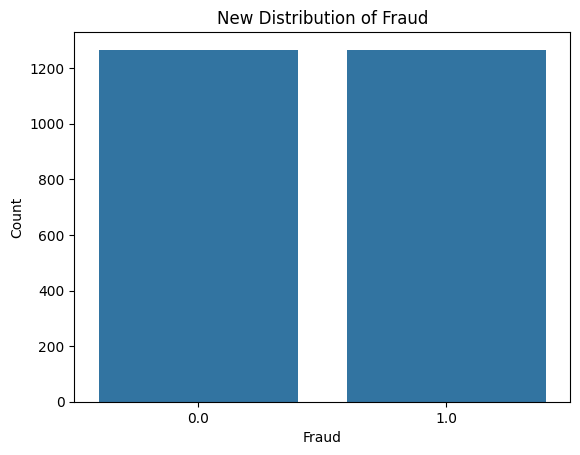

In [13]:
fraud_counts=data['is_fraud'].value_counts()
sns.barplot(x=fraud_counts.index,y=fraud_counts.values)
plt.title('New Distribution of Fraud')
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.show()

In [14]:
unused_cols=['Unnamed: 0','first','last','unix_time','street','gender','job','dob','city','state','trans_num','merchant']
data.drop(columns=unused_cols,inplace=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2532 entries, 2449 to 68133
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  2532 non-null   object 
 1   cc_num                 2532 non-null   int64  
 2   category               2532 non-null   object 
 3   amt                    2532 non-null   float64
 4   zip                    2532 non-null   float64
 5   lat                    2532 non-null   float64
 6   long                   2532 non-null   float64
 7   city_pop               2532 non-null   float64
 8   merch_lat              2532 non-null   float64
 9   merch_long             2532 non-null   float64
 10  is_fraud               2532 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 237.4+ KB


In [16]:
data['trans_date_trans_time']=pd.to_datetime(data['trans_date_trans_time'])
data['trans_day']=data['trans_date_trans_time'].dt.day
data['trans_month']=data['trans_date_trans_time'].dt.month
data['trans_year']=data['trans_date_trans_time'].dt.year
data['trans_hour']=data['trans_date_trans_time'].dt.hour
data['trans_minute']=data['trans_date_trans_time'].dt.minute
data.drop(columns=['trans_date_trans_time'],inplace=True)

In [17]:
encoder=LabelEncoder()
data['category']=encoder.fit_transform(data['category'])
data['cc_num']=encoder.fit_transform(data['cc_num'])

In [18]:
data.head()

,cc_num,category,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,trans_day,trans_month,trans_year,trans_hour,trans_minute
2449,78,4,281.06,28611.0,35.9946,-81.7266,885.0,36.430124,-81.179483,1.0,2,1,2019,1,6
2472,207,2,11.52,78208.0,29.4400,-98.4590,1595797.0,29.819364,-99.142791,1.0,2,1,2019,1,47
2523,207,4,276.31,78208.0,29.4400,-98.4590,1595797.0,29.273085,-98.836360,1.0,2,1,2019,3,5
2546,78,2,7.03,28611.0,35.9946,-81.7266,885.0,35.909292,-82.091010,1.0,2,1,2019,3,38
2553,207,4,275.73,78208.0,29.4400,-98.4590,1595797.0,29.786426,-98.683410,1.0,2,1,2019,3,55


In [19]:
scaler=StandardScaler()
data['amt']=scaler.fit_transform(data[['amt']])
data['zip']=scaler.fit_transform(data[['zip']])
data['city_pop']=scaler.fit_transform(data[['city_pop']])
data['cc_num']=encoder.fit_transform(data['cc_num'])

In [20]:
X=data.drop('is_fraud',axis=1)
y=data['is_fraud']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=0)

In [22]:
RFC=RandomForestClassifier(random_state=0)
RFC.fit(X_train,y_train)
y_pred=RFC.predict(X_test)

In [23]:
print('Accuracy:',accuracy_score(y_test, y_pred))
print('Precision:',precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 score:',f1_score(y_test, y_pred))
print('Confusion matrix:',confusion_matrix(y_test, y_pred))

Accuracy: 0.9526627218934911
Precision: 0.9538461538461539
Recall: 0.9538461538461539
F1 score: 0.9538461538461539
Confusion matrix: [[235  12]
 [ 12 248]]


Text(0.5, 1.0, 'Confusion Matrix')

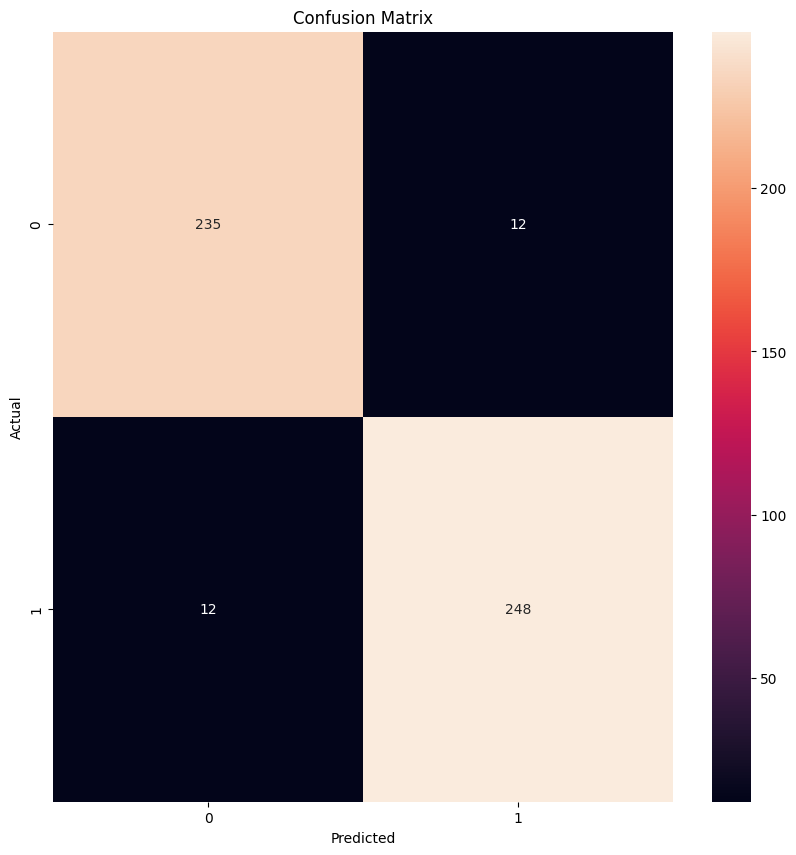

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')